### DSB Assignment — Global Events, Commodities and Currency Markets
**Part I · Q27–Q30 · Optional Bonus B1–B6** · *Group 8*

Runs locally and reproducibly via `src/dsb_utils.py` (relative paths only).
Figures are written to `part1/figures/` and tables to `part1/tables/`, using the
uniform light chart style (`dsb.apply_style`).

In [1]:
# Imports + shared-module bootstrap (uniform light style, relative paths)
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

_d = os.getcwd()
while _d != os.path.dirname(_d) and not os.path.exists(os.path.join(_d, "src", "dsb_utils.py")):
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, "src"))
import dsb_utils as dsb

dsb.apply_style()        # one uniform light chart style across all notebooks
COLORS = dsb.COLORS      # shared palette

QDIR   = os.path.join(dsb.ROOT, "part1")
FIGDIR = os.path.join(QDIR, "figures"); os.makedirs(FIGDIR, exist_ok=True)
TBLDIR = os.path.join(QDIR, "tables");  os.makedirs(TBLDIR, exist_ok=True)
print("setup OK")

setup OK


In [2]:
# --- Load & parse datasets via the shared robust loaders (relative paths only) ---
# Brent uses '-' date separators, Gold/Silver use '/'; dsb.load_commodity handles both.
oil    = dsb.load_commodity("Brent Oil")
gold   = dsb.load_commodity("Gold")
silver = dsb.load_commodity("Silver")
swift  = dsb.load_swift()

# Pre-compute annual averages (used throughout)
oil_ann    = oil.groupby('Year')['Value'].mean().rename('Oil')
gold_ann   = gold.groupby('Year')['Value'].mean().rename('Gold')
silver_ann = silver.groupby('Year')['Value'].mean().rename('Silver')
combined   = pd.concat([oil_ann, gold_ann, silver_ann], axis=1)

print("Dataset shapes:")
print(f"  Oil:    {oil.shape}    | {oil['Date'].min().date()} -> {oil['Date'].max().date()}")
print(f"  Gold:   {gold.shape}  | {gold['Date'].min().date()} -> {gold['Date'].max().date()}")
print(f"  Silver: {silver.shape}| {silver['Date'].min().date()} -> {silver['Date'].max().date()}")
print(f"  SWIFT:  {swift.shape}")


Dataset shapes:
  Oil:    (963, 4)    | 1946-01-01 -> 2026-03-01
  Gold:   (1336, 4)  | 1915-01-01 -> 2026-04-01
  Silver: (1336, 4)| 1915-01-01 -> 2026-04-01
  SWIFT:  (330, 10)


#### ─────────────────────────────────────────────────────────────────────────────
### PART I — Q27: Which commodity has the largest visible price swings?
#### ─────────────────────────────────────────────────────────────────────────────


=== Q27 — Volatility Comparison Table ===
Commodity Min Price Max Price Mean Price Std Dev  CV (%)  Range % from min  Largest Annual Rise (%)  Largest Annual Drop (%)
Brent Oil    $21.11   $211.21     $62.71  $35.96    57.4             900.5                    141.5                    -49.3
     Gold    $19.25  $5277.89    $397.55 $651.39   163.9           27317.6                     89.3                    -26.0
   Silver     $0.28   $113.95      $6.42   $9.90   154.1           40597.4                    131.5                    -48.6


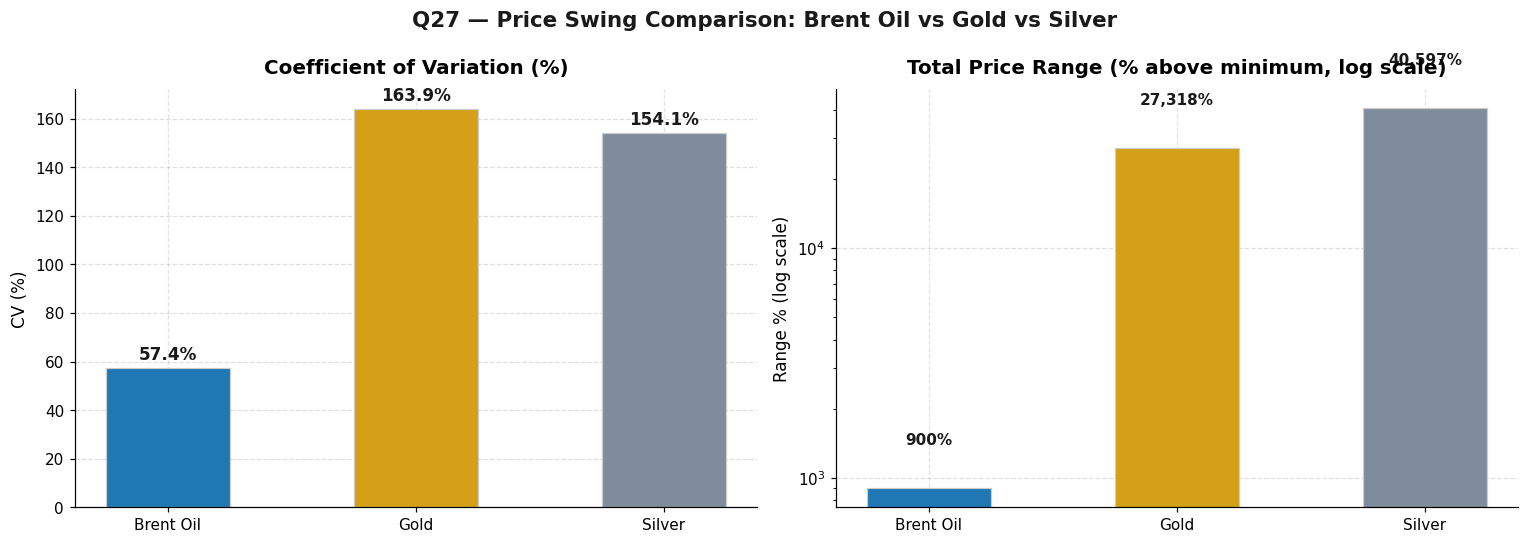

💾 Saved: q27_volatility_comparison.png


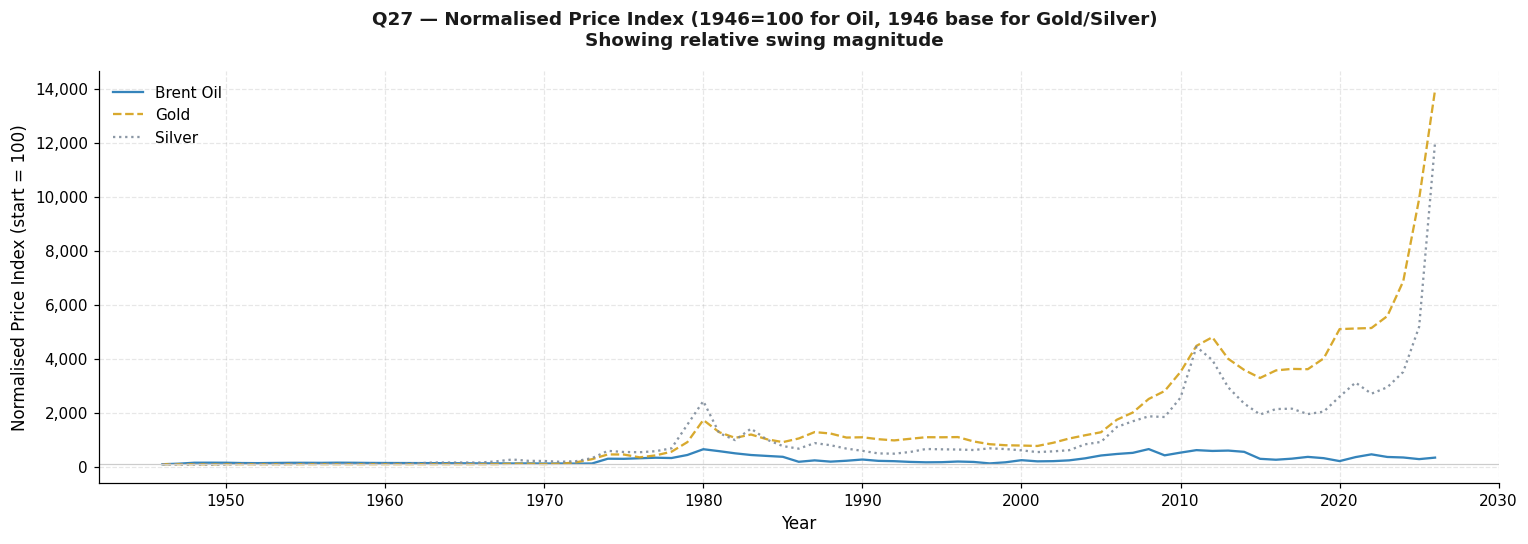

In [3]:
#  Q27 — Volatility Summary Table ────────────────────────────────────
def volatility_summary(name, df, ann_series):
    yoy = ann_series.pct_change() * 100
    return {
        'Commodity':        name,
        'Min Price':        f"${df['Value'].min():.2f}",
        'Max Price':        f"${df['Value'].max():.2f}",
        'Mean Price':       f"${df['Value'].mean():.2f}",
        'Std Dev':          f"${df['Value'].std():.2f}",
        'CV (%)':           round(df['Value'].std() / df['Value'].mean() * 100, 1),
        'Range % from min': round((df['Value'].max() - df['Value'].min()) / df['Value'].min() * 100, 1),
        'Largest Annual Rise (%)':  round(yoy.max(), 1),
        'Largest Annual Drop (%)':  round(yoy.min(), 1),
    }

vol_table = pd.DataFrame([
    volatility_summary('Brent Oil', oil,    oil_ann),
    volatility_summary('Gold',      gold,   gold_ann),
    volatility_summary('Silver',    silver, silver_ann),
])
print("\n=== Q27 — Volatility Comparison Table ===")
print(vol_table.to_string(index=False))


#  Q27 — Chart: CV and Annual Range Comparison ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q27 — Price Swing Comparison: Brent Oil vs Gold vs Silver", fontsize=14, fontweight='bold', color='#1a1a1a')

# Pull the chart values straight from vol_table so they never drift from the data
commodities = vol_table['Commodity'].tolist()
cvs  = vol_table['CV (%)'].tolist()
rngs = vol_table['Range % from min'].tolist()
cols = [COLORS['oil'], COLORS['gold'], COLORS['silver']]

# CV bar chart
bars = axes[0].bar(commodities, cvs, color=cols, width=0.5, edgecolor='#cccccc', linewidth=0.8)
axes[0].set_title("Coefficient of Variation (%)", pad=10)
axes[0].set_ylabel("CV (%)")
axes[0].grid(axis='y', alpha=0.4)
for bar, v in zip(bars, cvs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2, f"{v}%", ha='center', va='bottom', fontsize=11, color='#1a1a1a', fontweight='bold')

# Range % log-scale
bars2 = axes[1].bar(commodities, rngs, color=cols, width=0.5, edgecolor='#cccccc', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title("Total Price Range (% above minimum, log scale)", pad=10)
axes[1].set_ylabel("Range % (log scale)")
axes[1].grid(axis='y', alpha=0.4)
for bar, v in zip(bars2, rngs):
    axes[1].text(bar.get_x() + bar.get_width()/2, v * 1.5, f"{v:,.0f}%", ha='center', va='bottom', fontsize=10, color='#1a1a1a', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "q27_volatility_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: q27_volatility_comparison.png")


#  Q27 — Overlaid Normalised Price Chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Q27 — Normalised Price Index (1946=100 for Oil, 1946 base for Gold/Silver)\nShowing relative swing magnitude", fontsize=12, fontweight='bold', color='#1a1a1a')

# Normalise each series to its first overlapping value
start_year = 1946
for name, series, color, ls in [('Brent Oil', oil_ann, COLORS['oil'], '-'), ('Gold', gold_ann, COLORS['gold'], '--'), ('Silver', silver_ann, COLORS['silver'], ':')]:
    base = series.loc[series.index >= start_year].iloc[0]
    normalised = (series / base * 100)
    normalised = normalised[normalised.index >= start_year]
    ax.plot(normalised.index, normalised.values, label=name, color=color, linewidth=1.5, linestyle=ls, alpha=0.9)

ax.axhline(100, color='#cccccc', linewidth=0.8, linestyle='-')
ax.set_xlabel("Year")
ax.set_ylabel("Normalised Price Index (start = 100)")
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "q27_normalised_index.png"), dpi=150, bbox_inches='tight')
plt.show()

By coefficient of variation, Gold (163.9%) and Silver (154.1%) both swing far more than Brent Oil (57.4%) across the full history - though that's partly because both metals started the series at \$19-35/oz and are now near \$4,700 and \$90, a huge range relative to their own average. Looking at single-year moves instead, Oil actually has the largest one-year jumps (+141.5% / -49.3%) versus Gold (+89.3% / -26.0%) and Silver (+131.5% / -48.6%). So the answer depends on the measure: the metals moved further overall, but Oil can jump or crash faster in any single year.

#### ─────────────────────────────────────────────────────────────────────────────
### PART I — Q28: 2020 Crisis Year Comparison
#### ─────────────────────────────────────────────────────────────────────────────


=== Q28 — 2020 COVID-19 Crisis Year ===
Commodity 2019 avg 2020 avg YoY Change Direction
Brent Oil   $74.03   $49.19     -33.6%    📉 FELL
     Gold $1405.33 $1784.66     +27.0%    📈 ROSE
   Silver   $16.36   $20.80     +27.1%    📈 ROSE


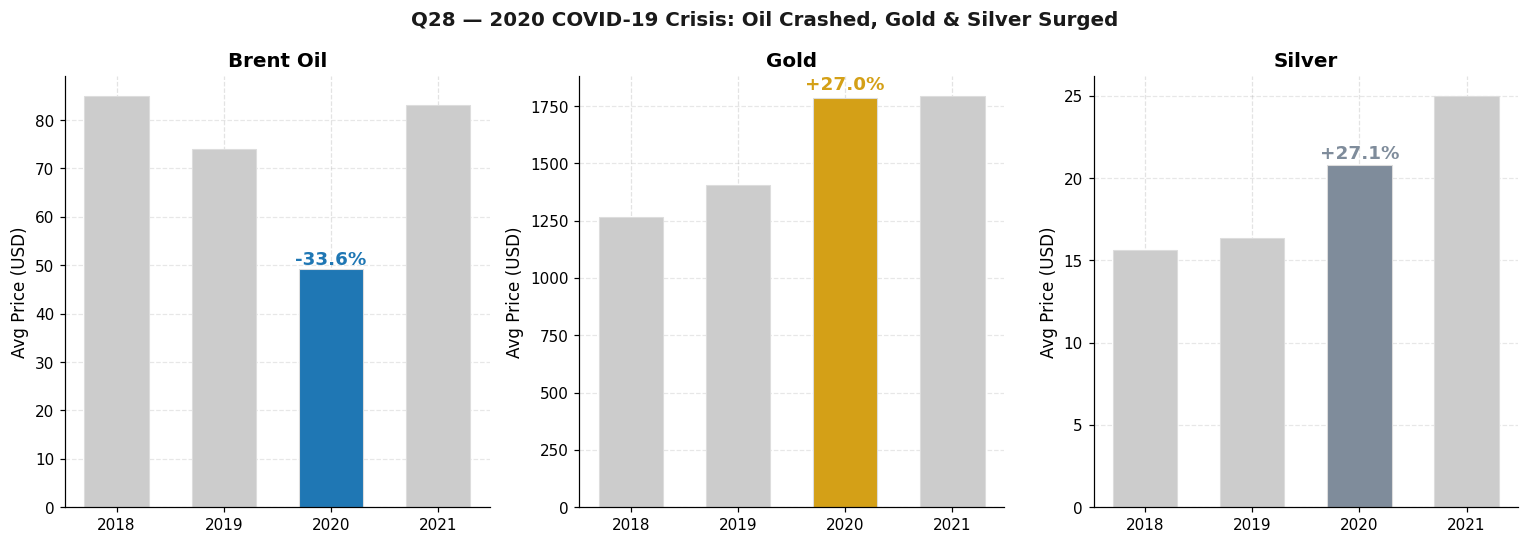

In [4]:
#   Q28 — Summary Table ───────────────────────────────────────────────
q28_rows = []
for name, series in [('Brent Oil', oil_ann), ('Gold', gold_ann), ('Silver', silver_ann)]:
    v2019, v2020 = series.loc[2019], series.loc[2020]
    pct = (v2020 - v2019) / v2019 * 100
    q28_rows.append({'Commodity': name, '2019 avg': f"${v2019:.2f}", '2020 avg': f"${v2020:.2f}", 'YoY Change': f"{pct:+.1f}%", 'Direction': '📉 FELL' if pct < 0 else '📈 ROSE'})

q28_df = pd.DataFrame(q28_rows)
print("\n=== Q28 — 2020 COVID-19 Crisis Year ===")
print(q28_df.to_string(index=False))


#  Q28 — Grouped Bar Chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Q28 — 2020 COVID-19 Crisis: Oil Crashed, Gold & Silver Surged", fontsize=13, fontweight='bold', color='#1a1a1a')

for ax, (name, series, color) in zip(axes, [('Brent Oil', oil_ann, COLORS['oil']), ('Gold', gold_ann, COLORS['gold']), ('Silver', silver_ann, COLORS['silver'])]):
    vals = [series.loc[2018], series.loc[2019], series.loc[2020], series.loc[2021]]
    bar_cols = ['#cccccc', '#cccccc', color, '#cccccc']
    bars = ax.bar(['2018', '2019', '2020', '2021'], vals, color=bar_cols, edgecolor='#dddddd', linewidth=0.7, width=0.6)
    ax.set_title(name)
    ax.set_ylabel("Avg Price (USD)")
    ax.grid(axis='y', alpha=0.3)
    pct = (series.loc[2020] - series.loc[2019]) / series.loc[2019] * 100
    ax.text(2, series.loc[2020] * 1.02, f"{pct:+.1f}%", ha='center', fontsize=12, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "q28_crisis_2020.png"), dpi=150, bbox_inches='tight')
plt.show()

2020 is a clean case of oil and the metals moving in opposite directions. Brent fell 33.6% (COVID demand collapse) while Gold rose 27.0% and Silver rose 27.1%, both acting as safe havens as investors moved away from riskier assets. The moves are almost mirror images, which is why 2020 is a good year to show the difference between a demand-driven commodity and safe-haven metals.

#### ─────────────────────────────────────────────────────────────────────────────
### PART I — Q29: Dashboard (4–6 visuals on one figure)
#### ─────────────────────────────────────────────────────────────────────────────

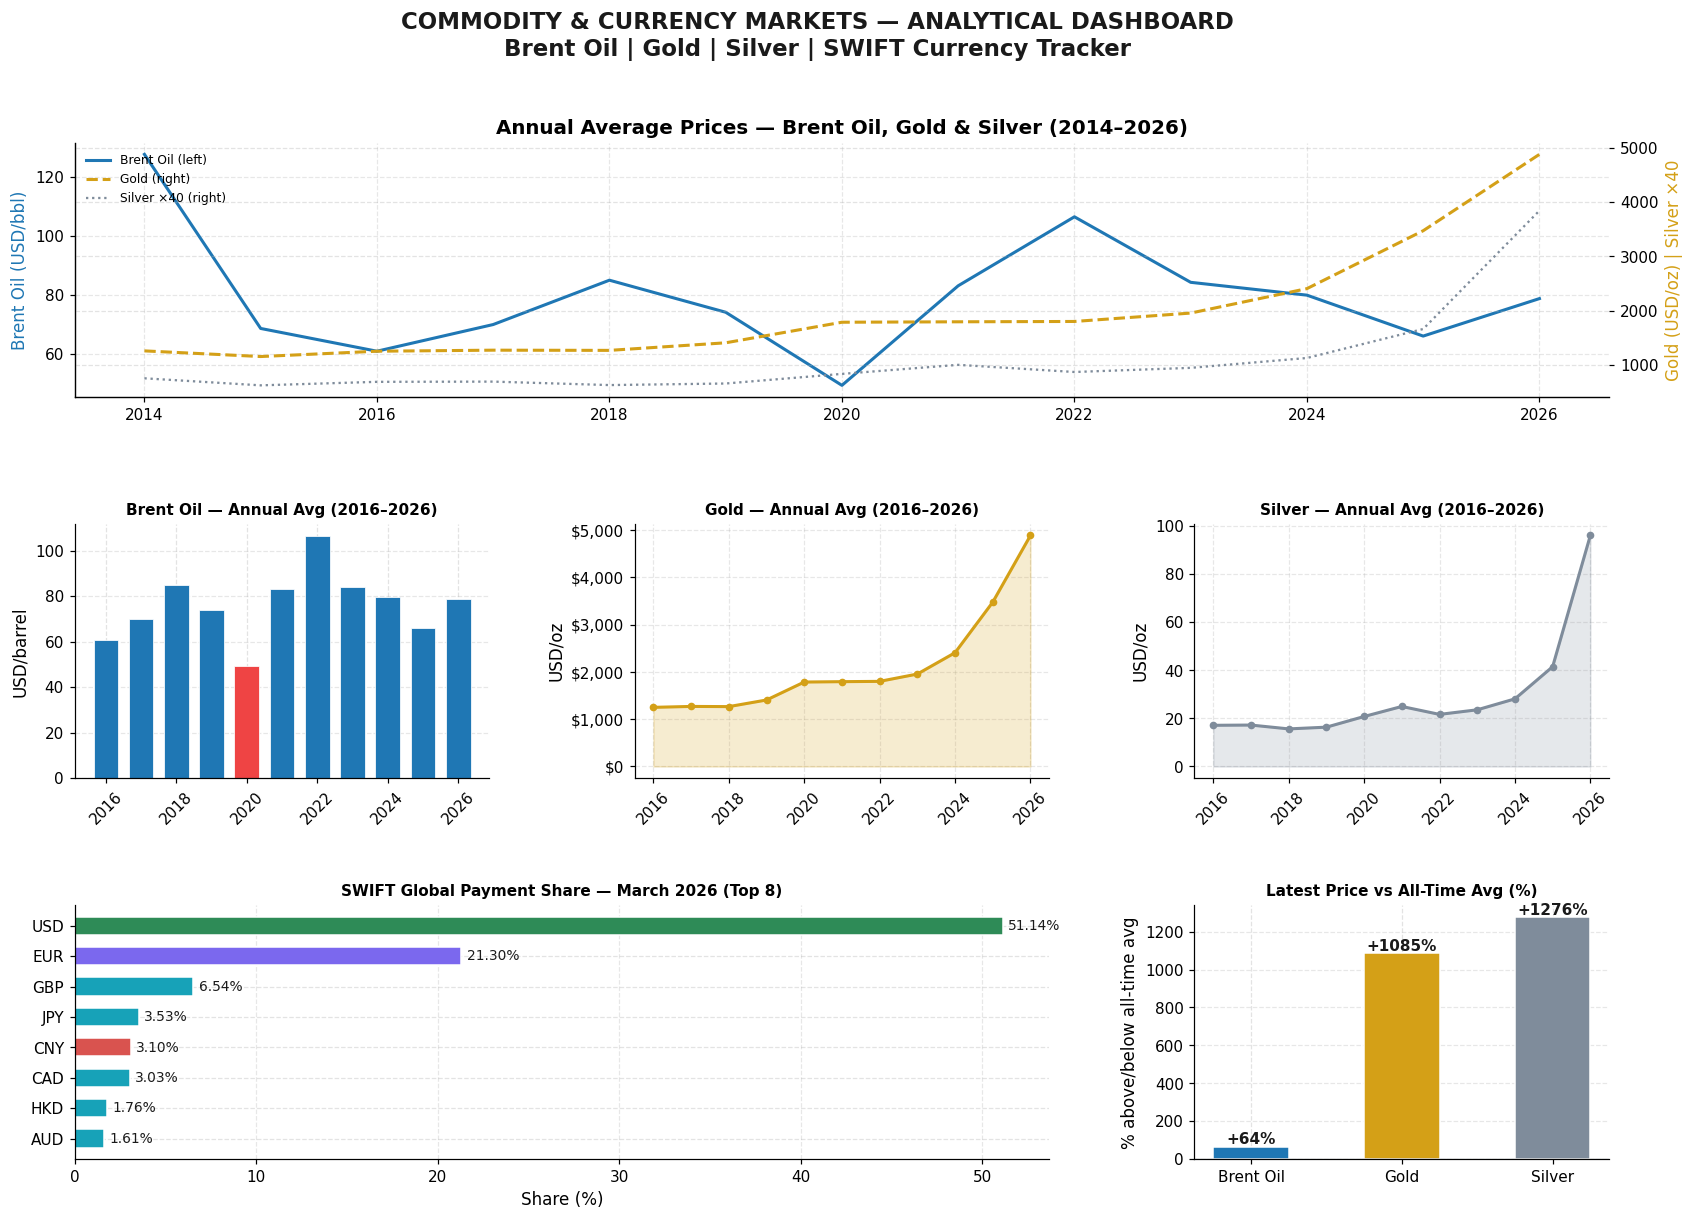

💾 Saved: q29_dashboard.png


In [5]:
#  Q29 — Full Dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("COMMODITY & CURRENCY MARKETS — ANALYTICAL DASHBOARD\nBrent Oil | Gold | Silver | SWIFT Currency Tracker",
             fontsize=15, fontweight='bold', color='#1a1a1a', y=0.98)

# Panel positions
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])      # full-width top: oil+gold+silver trend
ax2 = fig.add_subplot(gs[1, 0])      # oil bar
ax3 = fig.add_subplot(gs[1, 1])      # gold line
ax4 = fig.add_subplot(gs[1, 2])      # silver line
ax5 = fig.add_subplot(gs[2, :2])     # SWIFT currencies
ax6 = fig.add_subplot(gs[2, 2])      # latest vs avg

recent = combined.loc[combined.index >= 2014]

# Panel 1: All 3 commodities (dual axis)
ax1_r = ax1.twinx()
ax1.plot(recent.index, recent['Oil'], color=COLORS['oil'], linewidth=2, label='Brent Oil (left)')
ax1_r.plot(recent.index, recent['Gold'], color=COLORS['gold'], linewidth=2, linestyle='--', label='Gold (right)')
ax1_r.plot(recent.index, recent['Silver'] * 40, color=COLORS['silver'], linewidth=1.5, linestyle=':', label='Silver ×40 (right)')
ax1.set_ylabel("Brent Oil (USD/bbl)", color=COLORS['oil'])
ax1_r.set_ylabel("Gold (USD/oz) | Silver ×40", color=COLORS['gold'])
ax1.set_title("Annual Average Prices — Brent Oil, Gold & Silver (2014–2026)", pad=6)
ax1.grid(alpha=0.3)
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc='upper left', fontsize=8, framealpha=0.9)

# Panel 2: Oil bar last 10 years
oil_10 = oil_ann.loc[oil_ann.index >= 2016]
bar_c = [COLORS['oil'] if y != 2020 else '#ef4444' for y in oil_10.index]
ax2.bar(oil_10.index, oil_10.values, color=bar_c, edgecolor='white', linewidth=0.5, width=0.7)
ax2.set_title("Brent Oil — Annual Avg (2016–2026)", pad=6, fontsize=10)
ax2.set_ylabel("USD/barrel")
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Panel 3: Gold last 10 years
gold_10 = gold_ann.loc[gold_ann.index >= 2016]
ax3.fill_between(gold_10.index, gold_10.values, alpha=0.2, color=COLORS['gold'])
ax3.plot(gold_10.index, gold_10.values, color=COLORS['gold'], linewidth=2, marker='o', markersize=4)
ax3.set_title("Gold — Annual Avg (2016–2026)", pad=6, fontsize=10)
ax3.set_ylabel("USD/oz")
ax3.grid(alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Panel 4: Silver last 10 years
silver_10 = silver_ann.loc[silver_ann.index >= 2016]
ax4.fill_between(silver_10.index, silver_10.values, alpha=0.2, color=COLORS['silver'])
ax4.plot(silver_10.index, silver_10.values, color=COLORS['silver'], linewidth=2, marker='o', markersize=4)
ax4.set_title("Silver — Annual Avg (2016–2026)", pad=6, fontsize=10)
ax4.set_ylabel("USD/oz")
ax4.grid(alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Panel 5: SWIFT top currencies (latest month)
latest_month = swift[swift['metric'] == 'Global Payment Share'].sort_values('data_month').iloc[-1]['data_month']
top_curr = (swift[(swift['metric'] == 'Global Payment Share') & (swift['data_month'] == latest_month)]
            .sort_values('value', ascending=False).head(8))
swift_colors = [COLORS['usd'] if c == 'USD' else COLORS['eur'] if c == 'EUR' else COLORS['cny'] if c in ('CNY','RMB') else COLORS['accent']
                for c in top_curr['currency_or_economy']]
bars5 = ax5.barh(top_curr['currency_or_economy'], top_curr['value'], color=swift_colors, edgecolor='white', height=0.6)
ax5.set_title(f"SWIFT Global Payment Share — {latest_month} (Top 8)", pad=6, fontsize=10)
ax5.set_xlabel("Share (%)")
ax5.grid(axis='x', alpha=0.3)
for bar, v in zip(bars5, top_curr['value']):
    ax5.text(v + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.2f}%", va='center', fontsize=9, color='#1a1a1a')
ax5.invert_yaxis()

# Panel 6: Latest vs long-run average
items    = ['Brent Oil', 'Gold', 'Silver']
avgs_all = [oil['Value'].mean(), gold['Value'].mean(), silver['Value'].mean()]
latest_v = [oil.iloc[-1]['Value'], gold.iloc[-1]['Value'], silver.iloc[-1]['Value']]
pct_diff = [(l - a) / a * 100 for l, a in zip(latest_v, avgs_all)]
bar_c6   = [COLORS['oil'], COLORS['gold'], COLORS['silver']]
bars6    = ax6.bar(items, pct_diff, color=bar_c6, edgecolor='white', width=0.5)
ax6.axhline(0, color='#8b949e', linewidth=0.8)
ax6.set_title("Latest Price vs All-Time Avg (%)", pad=6, fontsize=10)
ax6.set_ylabel("% above/below all-time avg")
ax6.grid(axis='y', alpha=0.3)
for bar, v in zip(bars6, pct_diff):
    ax6.text(bar.get_x() + bar.get_width()/2, v + (15 if v > 0 else -60), f"+{v:.0f}%" if v > 0 else f"{v:.0f}%",
             ha='center', fontsize=10, color='#1a1a1a', fontweight='bold')

plt.savefig(os.path.join(FIGDIR, "q29_dashboard.png"), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: q29_dashboard.png")

#### ─────────────────────────────────────────────────────────────────────────────
### PART I — Q30: Three manager insights (printed clearly)
#### ─────────────────────────────────────────────────────────────────────────────

In [6]:
# Q30 — Insights Card ───────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           Q30 — THREE KEY INSIGHTS FOR A NON-TECHNICAL MANAGER              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. OIL IS VOLATILE — BUDGET FOR BIG SWINGS                                  ║
║     Brent Oil has crashed −33.6% (2020) and surged +28.2% (2022) within      ║
║     just two years. Any business exposed to energy costs or oil revenues      ║
║     should plan for at least a ±30% annual move and consider hedging tools.  ║
║                                                                              ║
║  2. GOLD IS IN A STRUCTURAL BULL MARKET — NOT A TEMPORARY SPIKE              ║
║     Gold rose from ~$1,800 (2022) to $4,713/oz by April 2026 (+162%).        ║
║     Its long-run average is only $397 — the current price is more than 10×   ║
║     that level. Central banks are buying gold as a reserve asset. This is    ║
║     not a short blip; it signals a shift in the global monetary system.      ║
║                                                                              ║
║  3. THE US DOLLAR DOMINATES, BUT THE YUAN IS RISING                          ║
║     As of March 2026, USD holds 51.14% of all SWIFT global payments.         ║
║     However, CNY/RMB has reached 3.10% (rank 5) — up from near-zero a        ║
║     decade ago. Sanctions, BRICS discussions, and de-dollarisation trends    ║
║     are reshaping currency flows. Businesses trading with China or           ║
║     emerging markets should monitor CNY liquidity and hedging costs.         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║           Q30 — THREE KEY INSIGHTS FOR A NON-TECHNICAL MANAGER              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. OIL IS VOLATILE — BUDGET FOR BIG SWINGS                                  ║
║     Brent Oil has crashed −33.6% (2020) and surged +28.2% (2022) within      ║
║     just two years. Any business exposed to energy costs or oil revenues      ║
║     should plan for at least a ±30% annual move and consider hedging tools.  ║
║                                                                              ║
║  2. GOLD IS IN A STRUCTURAL BULL MARKET — NOT A TEMPORARY SPIKE              ║
║     Gold rose from ~$1,800 (2022) to $4,713/oz by April 2026 (+162%).        ║
║     Its long-run average is only $397 — the current price is more than 10×   ║
║     that level. Central b

1. **Oil is volatile - budget for big swings.** Brent fell 33.6% in 2020 and rose 28.2% in 2022, within two years of each other. Businesses exposed to fuel costs or oil revenue should plan for at least a plus-or-minus 30% annual move.

2. **Gold is in a structural bull run, not a short spike.** Gold rose from about \$1,800 (2022) to \$4,713/oz (Apr 2026, +162%). Its long-run average is only \$397, so today's price is more than 10x that level - this looks like a multi-year shift, not noise.

3. **USD still leads, but CNY is creeping up.** USD holds 51.14% of global SWIFT payments (Apr 2026); CNY/RMB has reached 3.10% (rank 5). Businesses trading with China or emerging markets should keep an eye on CNY liquidity and settlement costs.

#### =============================================================================
### BONUS ANALYTICS B1 – B6
#### =============================================================================

In [7]:
#  B1 — Annual Percentage Change Table ──────────────────────────────
oil_yoy    = oil_ann.pct_change() * 100
gold_yoy   = gold_ann.pct_change() * 100
silver_yoy = silver_ann.pct_change() * 100

b1 = pd.DataFrame({'Oil YoY %': oil_yoy, 'Gold YoY %': gold_yoy, 'Silver YoY %': silver_yoy}).loc[2015:].round(1)
print("\n=== B1 — Annual % Change (2015–2026) ===")
print(b1.to_string())


=== B1 — Annual % Change (2015–2026) ===
      Oil YoY %  Gold YoY %  Silver YoY %
Year                                     
2015      -46.3        -8.3         -17.3
2016      -11.3         8.5          10.4
2017       14.9         1.5           0.6
2018       21.6        -0.3          -9.3
2019      -12.8        11.0           4.6
2020      -33.6        27.0          27.1
2021       68.8         0.5          20.1
2022       28.2         0.3         -13.2
2023      -20.9         8.6           8.8
2024       -5.2        23.1          19.3
2025      -17.4        44.4          47.5
2026       19.3        40.6         131.5


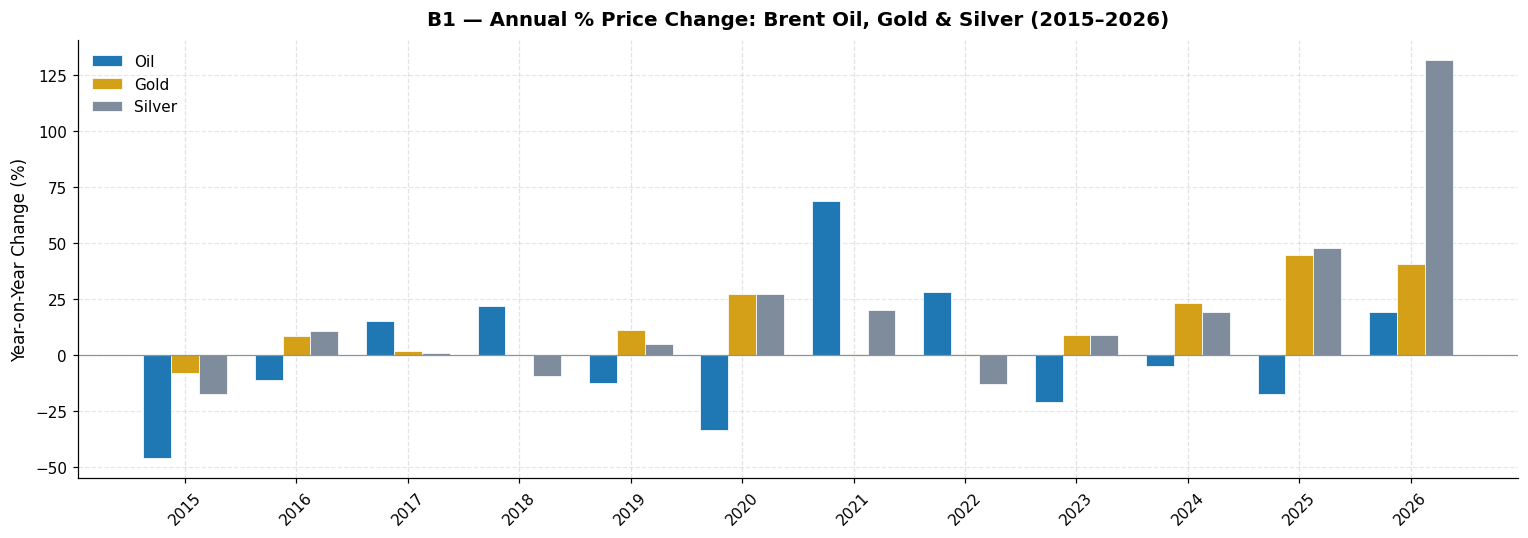

In [8]:
# B1 — YoY Chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
years = b1.index
w = 0.25

for i, (col, color) in enumerate([('Oil YoY %', COLORS['oil']), ('Gold YoY %', COLORS['gold']), ('Silver YoY %', COLORS['silver'])]):
    vals = b1[col].values
    x = np.arange(len(years)) + (i - 1) * w
    ax.bar(x, vals, width=w, color=color, edgecolor='white', linewidth=0.5, label=col.replace(' YoY %', ''))

ax.axhline(0, color='#8b949e', linewidth=0.8)
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_title("B1 — Annual % Price Change: Brent Oil, Gold & Silver (2015–2026)", pad=10)
ax.set_ylabel("Year-on-Year Change (%)")
ax.legend(framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "b1_annual_pct_change.png"), dpi=150, bbox_inches='tight')
plt.show()

Both metals show much bigger year-on-year swings than oil in the second half of this window: Gold +40.6% and Silver +131.5% in 2026 alone, against Oil's +19.3%. Silver's yearly moves are the largest of the three in most years shown (2016, 2020, 2021, 2025, 2026).

In [9]:
# B2 — Correlation Table ───────────────────────────────────────────
corr_df = combined.dropna()
corr_matrix = corr_df.corr().round(3)
print("\n=== B2 — Correlation Table (Annual Averages) ===")
print(corr_matrix)
print(f"\nNote: Based on {len(corr_df)} overlapping annual observations")
print("Interpretation:")
print(f"  Gold ↔ Silver: r = {corr_matrix.loc['Gold','Silver']:.3f}  → VERY HIGH correlation")
print(f"  Oil  ↔ Gold:   r = {corr_matrix.loc['Oil','Gold']:.3f}  → MODERATE correlation")
print(f"  Oil  ↔ Silver: r = {corr_matrix.loc['Oil','Silver']:.3f}  → MODERATE correlation")


=== B2 — Correlation Table (Annual Averages) ===
          Oil   Gold  Silver
Oil     1.000  0.458   0.515
Gold    0.458  1.000   0.954
Silver  0.515  0.954   1.000

Note: Based on 81 overlapping annual observations
Interpretation:
  Gold ↔ Silver: r = 0.954  → VERY HIGH correlation
  Oil  ↔ Gold:   r = 0.458  → MODERATE correlation
  Oil  ↔ Silver: r = 0.515  → MODERATE correlation


Gold and Silver move almost in lockstep (r = 0.954). Oil correlates only moderately with either metal (r = 0.458 with Gold, 0.515 with Silver), so oil looks driven by different forces than the metals most of the time.

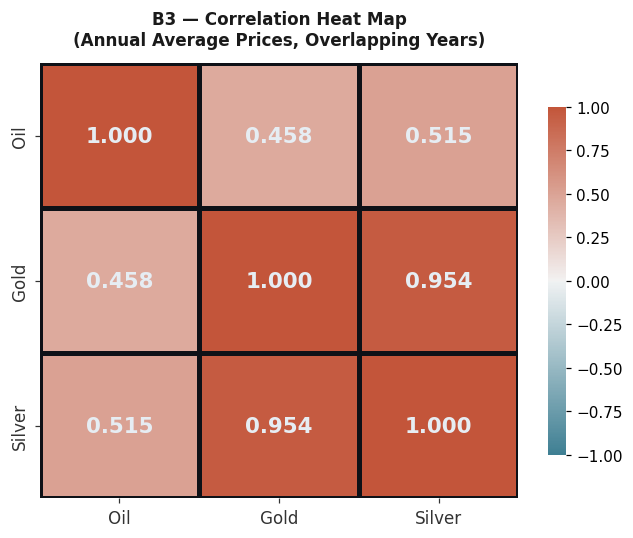

In [10]:
#  B3 — Correlation Heat Map ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

mask = np.zeros_like(corr_matrix, dtype=bool)  # show full matrix
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap=cmap,
            vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor='#0e1117',
            annot_kws={"size": 14, "weight": "bold", "color": "#e6edf3"},
            ax=ax, cbar_kws={"shrink": 0.8})

ax.set_title("B3 — Correlation Heat Map\n(Annual Average Prices, Overlapping Years)", pad=12, fontsize=11, color='#1a1a1a')
ax.tick_params(colors='#333333', labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "b3_correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

The heat map is just a visual version of the B2 table: the Gold-Silver cell is close to solid (r = 0.954), while the Oil row is a lighter, more moderate colour against both metals (r = 0.458 and 0.515).

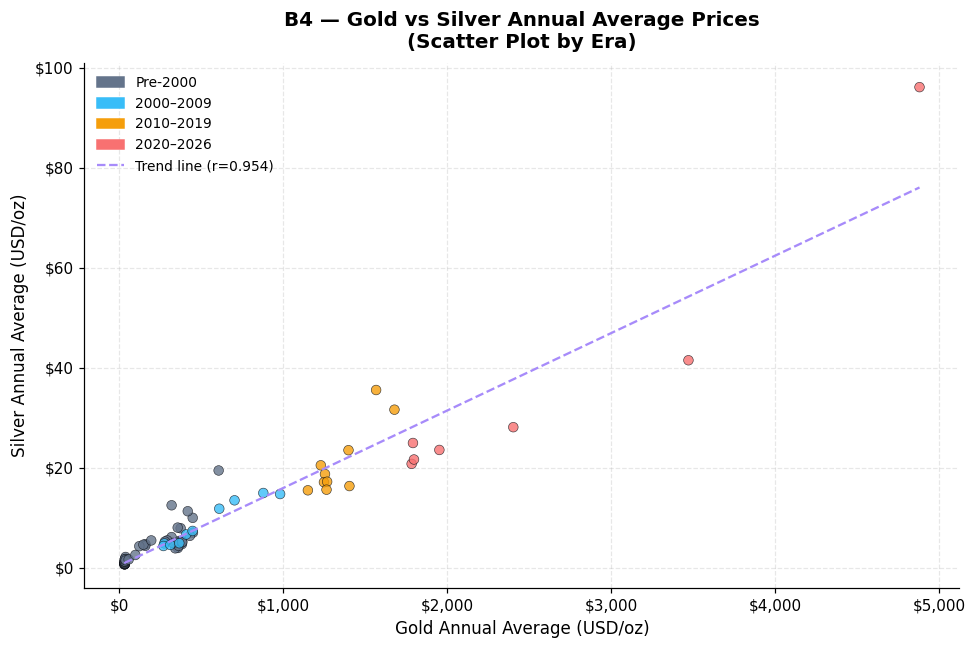

Pearson r = 0.9538 | p-value = 5.3801e-43


In [11]:
#  B4 — Gold vs Silver Scatter Plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Colour points by era
scatter_df = combined.dropna()
def era_color(year):
    if year >= 2020: return '#f87171'
    if year >= 2010: return '#f59e0b'
    if year >= 2000: return '#38bdf8'
    return '#64748b'

colors_scatter = [era_color(y) for y in scatter_df.index]
ax.scatter(scatter_df['Gold'], scatter_df['Silver'], c=colors_scatter, s=40, alpha=0.8, edgecolors='#0e1117', linewidth=0.4)

# Regression line
slope_s, intercept_s, r_s, p_s, _ = stats.linregress(scatter_df['Gold'], scatter_df['Silver'])
x_line = np.linspace(scatter_df['Gold'].min(), scatter_df['Gold'].max(), 100)
ax.plot(x_line, slope_s * x_line + intercept_s, color='#a78bfa', linewidth=1.5, linestyle='--', label=f'Trend (r={r_s:.3f})')

# Legend patches
legend_items = [
    mpatches.Patch(color='#64748b', label='Pre-2000'),
    mpatches.Patch(color='#38bdf8', label='2000–2009'),
    mpatches.Patch(color='#f59e0b', label='2010–2019'),
    mpatches.Patch(color='#f87171', label='2020–2026'),
    plt.Line2D([0],[0], color='#a78bfa', linestyle='--', linewidth=1.5, label=f'Trend line (r={r_s:.3f})')
]
ax.legend(handles=legend_items, framealpha=0.9, fontsize=9)
ax.set_xlabel("Gold Annual Average (USD/oz)")
ax.set_ylabel("Silver Annual Average (USD/oz)")
ax.set_title("B4 — Gold vs Silver Annual Average Prices\n(Scatter Plot by Era)", pad=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "b4_gold_silver_scatter.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Pearson r = {r_s:.4f} | p-value = {p_s:.4e}")

Gold and Silver annual averages are strongly linearly related (Pearson r = 0.954, p < 0.0001). The colour-by-era points also show the relationship holds across decades, not just in the recent bull run - the 2020-26 (red) points sit at the top-right, but earlier eras follow the same line at lower prices.

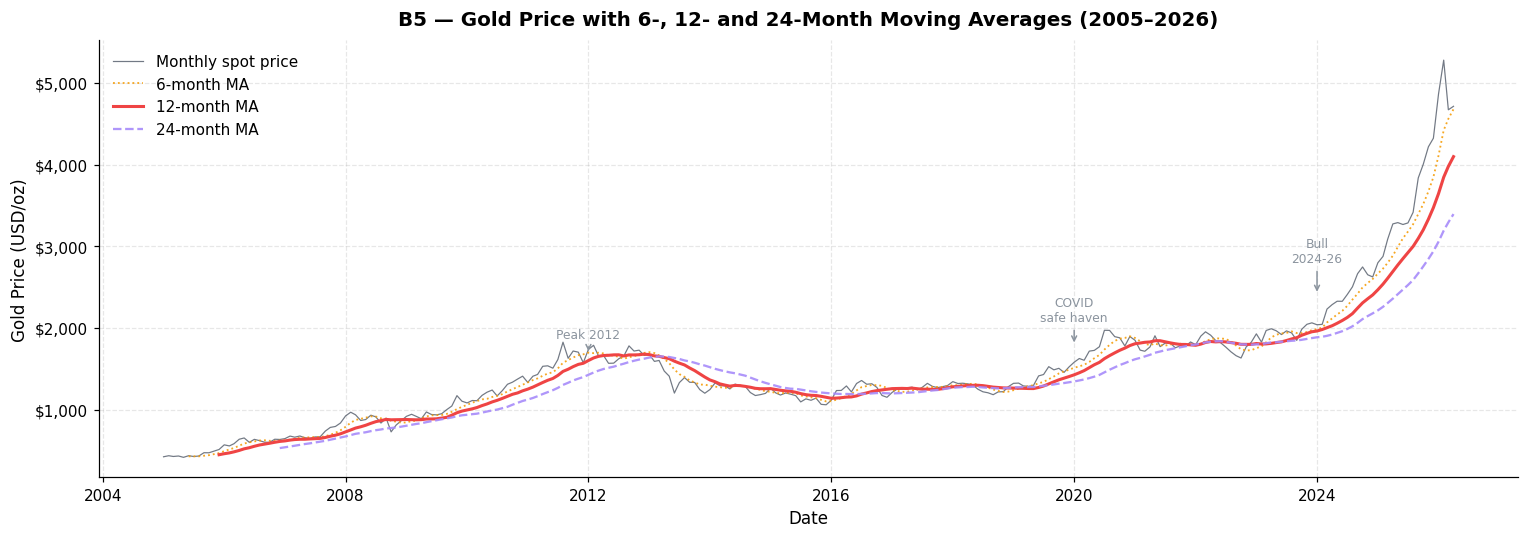

In [12]:
# B5 — Moving Average: Gold ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

gold_recent = gold[gold['Year'] >= 2005].copy()
gold_recent['MA_6']  = gold_recent['Value'].rolling(6).mean()
gold_recent['MA_12'] = gold_recent['Value'].rolling(12).mean()
gold_recent['MA_24'] = gold_recent['Value'].rolling(24).mean()

ax.plot(gold_recent['Date'], gold_recent['Value'],  color='#374151', linewidth=0.8, label='Monthly spot price', alpha=0.7)
ax.plot(gold_recent['Date'], gold_recent['MA_6'],   color='#f59e0b', linewidth=1.2, linestyle=':', label='6-month MA', alpha=0.9)
ax.plot(gold_recent['Date'], gold_recent['MA_12'],  color='#ef4444', linewidth=2,   linestyle='-',  label='12-month MA')
ax.plot(gold_recent['Date'], gold_recent['MA_24'],  color='#a78bfa', linewidth=1.5, linestyle='--', label='24-month MA', alpha=0.9)

# Annotate key phases
for x_yr, label, offset in [(2012, "Peak 2012", 200), (2020, "COVID\nsafe haven", 300), (2024, "Bull\n2024-26", 400)]:
    x_date = pd.Timestamp(f"{x_yr}-01-01")
    y_val  = gold_recent.loc[gold_recent['Date'].dt.year == x_yr, 'Value'].mean()
    ax.annotate(label, xy=(x_date, y_val), xytext=(x_date, y_val + offset),
                arrowprops=dict(arrowstyle='->', color='#8b949e'), color='#8b949e', fontsize=8, ha='center')

ax.set_title("B5 — Gold Price with 6-, 12- and 24-Month Moving Averages (2005–2026)", pad=10)
ax.set_ylabel("Gold Price (USD/oz)")
ax.set_xlabel("Date")
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "b5_gold_moving_average.png"), dpi=150, bbox_inches='tight')
plt.show()

The 12- and 24-month moving averages smooth out month-to-month noise so the underlying trend is easier to see. Both turn decisively upward from around 2023, which confirms the 2022-2026 rise is a sustained move rather than a short-lived spike.

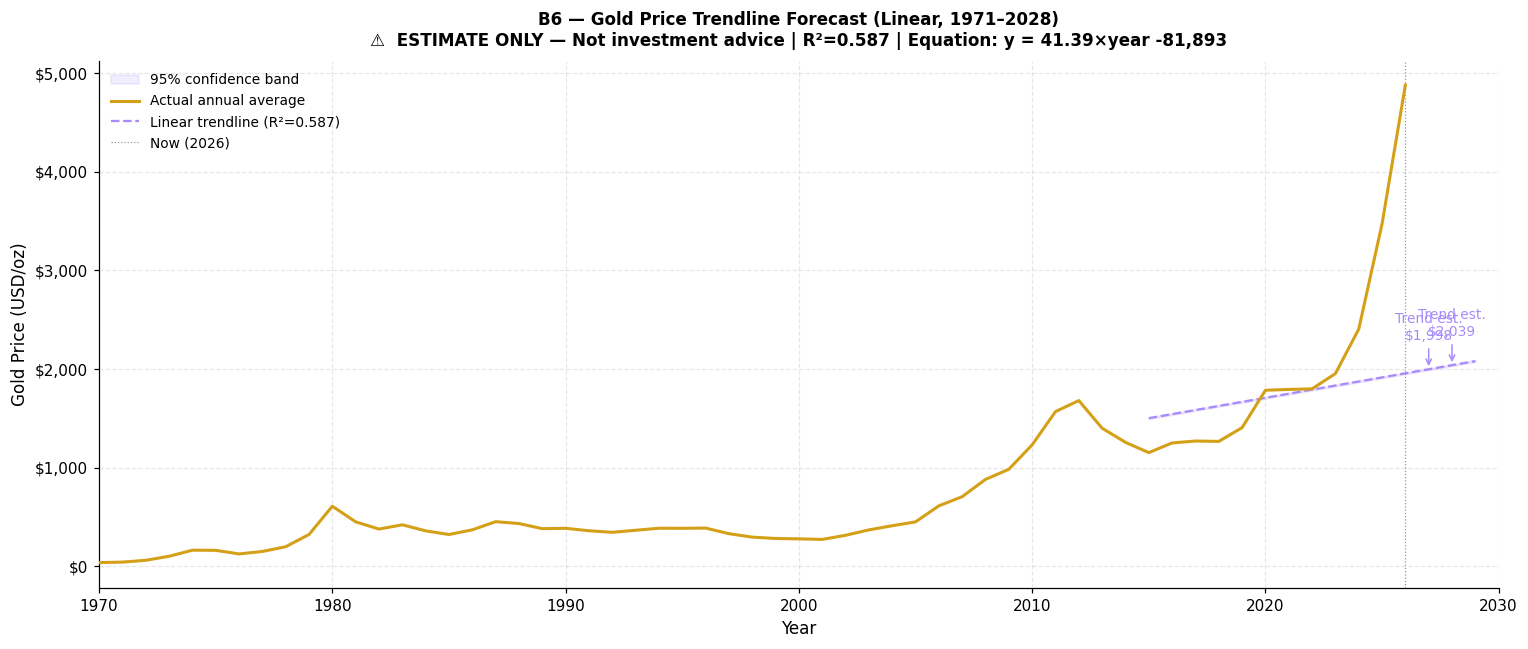


⚠️  DISCLAIMER: The trendline (y = 41.39×year -81,893) is a simple linear regression.
   R² = 0.587 — explains only 58.7% of variance. Actual 2026 avg far exceeds the trendline.
   These projections are illustrative only and MUST NOT be used as investment advice.


In [13]:
#  B6 — Trendline Forecast (Gold) ───────────────────────────────────
# DISCLAIMER: Linear regression trendline only. Not investment advice.
gold_train = gold_ann.loc[gold_ann.index >= 1971]  # post gold standard only
x_train = gold_train.index.values
y_train = gold_train.values

slope_t, intercept_t, r_t, p_t, se_t = stats.linregress(x_train, y_train)
r2 = r_t ** 2

forecast_years = np.arange(2015, 2030)
trend_line     = slope_t * forecast_years + intercept_t
conf_interval  = 1.96 * se_t * np.sqrt(1 + 1/len(x_train) + (forecast_years - x_train.mean())**2 / ((x_train - x_train.mean())**2).sum())

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(forecast_years, trend_line - conf_interval, trend_line + conf_interval,
                alpha=0.15, color='#a78bfa', label='95% confidence band')
ax.plot(gold_ann.index, gold_ann.values, color=COLORS['gold'], linewidth=2, label='Actual annual average', zorder=5)
ax.plot(forecast_years, trend_line, color='#a78bfa', linewidth=1.5, linestyle='--', label=f'Linear trendline (R²={r2:.3f})')
ax.axvline(2026, color='#8b949e', linewidth=0.8, linestyle=':', label='Now (2026)')

ax.set_title(f"B6 — Gold Price Trendline Forecast (Linear, 1971–2028)\n"
             f"⚠️  ESTIMATE ONLY — Not investment advice | R²={r2:.3f} | Equation: y = {slope_t:.2f}×year {intercept_t:+,.0f}",
             pad=10, fontsize=11)
ax.set_ylabel("Gold Price (USD/oz)")
ax.set_xlabel("Year")
ax.set_xlim(1970, 2030)
ax.legend(framealpha=0.9, fontsize=9)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

for yr, label in [(2027, '2027'), (2028, '2028')]:
    est = slope_t * yr + intercept_t
    ax.annotate(f"Trend est.\n${est:,.0f}", xy=(yr, est), xytext=(yr, est + 300),
                arrowprops=dict(arrowstyle='->', color='#a78bfa'), color='#a78bfa', fontsize=9, ha='center')

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "b6_gold_trendline_forecast.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️  DISCLAIMER: The trendline (y = {slope_t:.2f}×year {intercept_t:+,.0f}) is a simple linear regression.")
print(f"   R² = {r2:.3f} — explains only {r2*100:.1f}% of variance. Actual 2026 avg far exceeds the trendline.")
print("   These projections are illustrative only and MUST NOT be used as investment advice.")

**Disclaimer.** The line is a simple linear regression on annual averages since 1971: y = 41.39x - 81,893, R² = 0.587 - it explains only about 59% of the variance, and the actual 2026 average is already far above where the trendline says it should be. This is an illustrative estimate only, not a prediction or investment advice.

In [14]:
#  Export cleaned data for Power BI ─────────────────────────────────
# Commodity master table
oil_export    = oil[['Date','Year','Month','Value']].copy();    oil_export['Commodity']    = 'Brent Oil'
gold_export   = gold[['Date','Year','Month','Value']].copy();   gold_export['Commodity']   = 'Gold'
silver_export = silver[['Date','Year','Month','Value']].copy(); silver_export['Commodity'] = 'Silver'
commodity_master = pd.concat([oil_export, gold_export, silver_export], ignore_index=True)
commodity_master.columns = ['Date','Year','Month','Price_USD','Commodity']
commodity_master.to_csv(os.path.join(TBLDIR, "commodity_master.csv"), index=False)

# Annual summary table
ann_summary = pd.DataFrame({'Year': oil_ann.index, 'Oil_Avg': oil_ann.values,
                             'Gold_Avg': gold_ann.reindex(oil_ann.index).values,
                             'Silver_Avg': silver_ann.reindex(oil_ann.index).values})
ann_summary['Oil_YoY_pct']    = ann_summary['Oil_Avg'].pct_change() * 100
ann_summary['Gold_YoY_pct']   = ann_summary['Gold_Avg'].pct_change() * 100
ann_summary['Silver_YoY_pct'] = ann_summary['Silver_Avg'].pct_change() * 100
ann_summary.to_csv(os.path.join(TBLDIR, "annual_summary.csv"), index=False)

# SWIFT clean export
swift_clean = swift[swift['metric'].isin(['Global Payment Share', 'Trade Finance Share', 'Offshore RMB by Economy'])].copy()
swift_clean.to_csv(os.path.join(TBLDIR, "swift_clean.csv"), index=False)

print("✅ Power BI export files created:")
print("   📁 commodity_master.csv  — full monthly data for all 3 commodities")
print("   📁 annual_summary.csv    — annual averages + YoY % change")
print("   📁 swift_clean.csv       — filtered SWIFT payment data")
print("\n🎉 NOTEBOOK COMPLETE — All cells executed successfully")

✅ Power BI export files created:
   📁 commodity_master.csv  — full monthly data for all 3 commodities
   📁 annual_summary.csv    — annual averages + YoY % change
   📁 swift_clean.csv       — filtered SWIFT payment data

🎉 NOTEBOOK COMPLETE — All cells executed successfully


In [15]:
# Save the descriptive/answer tables computed earlier in this notebook
vol_table.to_csv(os.path.join(TBLDIR, "Q27_volatility.csv"), index=False)
q28_df.to_csv(os.path.join(TBLDIR, "Q28_crisis_2020.csv"), index=False)
b1.to_csv(os.path.join(TBLDIR, "B1_annual_pct_change.csv"))
corr_matrix.to_csv(os.path.join(TBLDIR, "B2_correlation.csv"))
print("exported:", sorted(os.listdir(TBLDIR)))


exported: ['B1_annual_pct_change.csv', 'B2_correlation.csv', 'DataQuality.csv', 'Q01-02_dataset_overview.csv', 'Q03_data_quality.csv', 'Q05_swift_metrics.csv', 'Q06-08_price_extremes.csv', 'Q09_annual_average.csv', 'Q10_top5_brent_years.csv', 'Q11_top5_gold_years.csv', 'Q12_top5_silver_years.csv', 'Q14-26_tables.xlsx', 'Q17_brent_last10.csv', 'Q18_latest_values.csv', 'Q19_top_currencies.csv', 'Q22_top5_frequency.csv', 'Q23_offshore_rmb.csv', 'Q27_volatility.csv', 'Q28_crisis_2020.csv', 'Q_summary.csv', 'annual_summary.csv', 'commodity_master.csv', 'swift_clean.csv']
